In [2]:
!pip install gTTS


  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gTTS]


GENERANDO DATASET V7

Generando ADDRESSED...


ADDRESSED: 100%|██████████| 98/98 [00:53<00:00,  1.84it/s]


ADDRESSED generados: 98

Generando NOT_ADDRESSED...


NOT_ADDRESSED: 100%|██████████| 88/88 [00:49<00:00,  1.77it/s]

NOT_ADDRESSED generados: 88

Dataset total: 186 samples
Guardado: addressee_dataset_v7.pkl (27.60 MB)


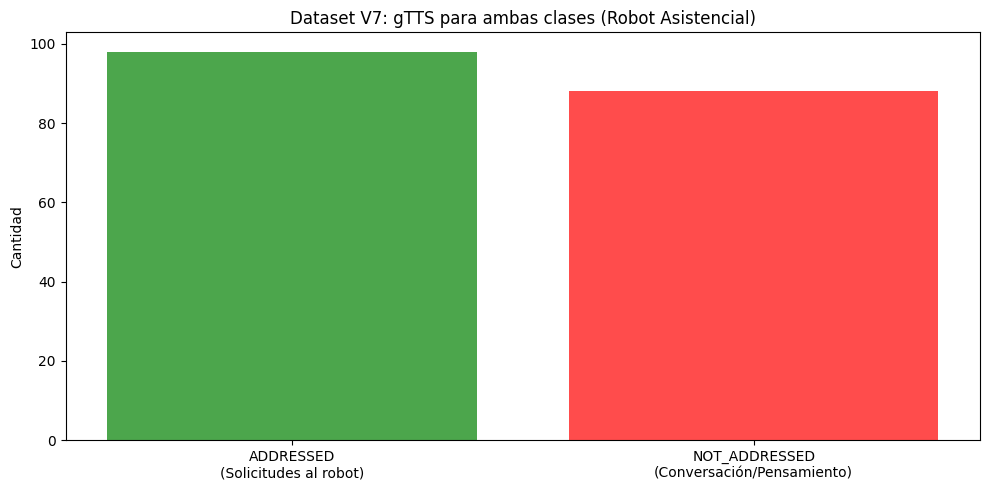


EJEMPLOS DATASET V7

ADDRESSED (2 ejemplos):
  Frase: 'Can you help me get up from the bed please'
  Contexto: User with mobility issues is looking at me from bed. Morning routine. I can phys...

  Frase: 'I need help standing up from this chair'
  Contexto: Elderly user looking at me. They have difficulty with balance. I can provide phy...

NOT_ADDRESSED (2 ejemplos):
  Frase: 'Where did I put my reading glasses'
  Contexto: User looking around the room, not at me. Thinking aloud about lost item....

  Frase: 'I should really call Maria tomorrow'
  Contexto: User looking at window, not at me. Self-reminder. Not directed at me....

DATASET V7 CREADO


In [6]:
# %%
# ============================================
# DATASET V7: gTTS PARA AMBAS CLASES
# Robot Asistencial con Contexto
# ============================================

import os
import io
import numpy as np
import pickle
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import soundfile as sf
import librosa
from gtts import gTTS

SR = 16000
MAX_DURATION = 5.0

# %%
# FUNCIONES

def generate_gtts_audio(text, sr=16000):
    """Genera audio con gTTS"""
    try:
        tts = gTTS(text=text, lang='en')
        fp = io.BytesIO()
        tts.write_to_fp(fp)
        fp.seek(0)
        audio, orig_sr = sf.read(fp)
        if len(audio.shape) > 1:
            audio = audio.mean(axis=1)
        if orig_sr != sr:
            audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=sr)
        audio = audio.astype(np.float32)
        if np.abs(audio).max() > 0:
            audio = audio / np.abs(audio).max()
        return audio
    except Exception as e:
        print(f"Error gTTS: {e}")
        return None

def add_background_noise(audio, noise_level=0.03):
    """Agrega ruido de fondo sutil"""
    noise = np.random.randn(len(audio)) * noise_level
    mixed = audio + noise
    mixed = mixed / np.abs(mixed).max()
    return mixed.astype(np.float32)

# %%
# DATOS ADDRESSED (100 muestras)
# Usuario MIRA al robot y hace solicitud

ADDRESSED_DATA = [
    # === ASISTENCIA FÍSICA ===
    {"transcription": "Can you help me get up from the bed please", 
     "context": "User with mobility issues is looking at me from bed. Morning routine. I can physically assist them to stand."},
    {"transcription": "I need help standing up from this chair",
     "context": "Elderly user looking at me. They have difficulty with balance. I can provide physical support."},
    {"transcription": "Please help me walk to the bathroom",
     "context": "User with mobility issues looking at me. They need support to walk. I can assist movement."},
    {"transcription": "Can you support me while I sit down",
     "context": "Elderly user looking at me. They need balance assistance. I can help them sit safely."},
    {"transcription": "I fell down please help me get up",
     "context": "User on floor looking at me with distress. Emergency situation. I can lift them and call for help."},
    {"transcription": "Help me get into the wheelchair",
     "context": "User with no arms looking at me. They need transfer assistance. I can help them into wheelchair."},
    {"transcription": "Can you help me lie down on the bed",
     "context": "Elderly user looking at me. They are tired. I can assist them to bed safely."},
    {"transcription": "I need you to help me change position",
     "context": "User with mobility issues in bed looking at me. Comfort issue. I can reposition them."},
    {"transcription": "Please support my back while I stand",
     "context": "Elderly user looking at me attempting to stand. Balance concern. I can provide support."},
    {"transcription": "Can you lift my legs onto the bed",
     "context": "User with no arms looking at me from bed edge. They cannot do it alone. I can assist."},
    
    # === CONTROL IoT ===
    {"transcription": "Please turn on the lights in here",
     "context": "User with visual impairment looking at me. Room is dark. I can control smart lights."},
    {"transcription": "Can you turn off the bedroom lights",
     "context": "Elderly user looking at me from bed. Bedtime. I can control lighting."},
    {"transcription": "Make the lights brighter please",
     "context": "User with low vision looking at me. They need more light. I can adjust intensity."},
    {"transcription": "Dim the lights a little bit",
     "context": "User looking at me. Lights too bright. I can dim them."},
    {"transcription": "Please open the window for fresh air",
     "context": "User with no hands looking at me. Room is stuffy. I can control smart windows."},
    {"transcription": "Can you close the window it is cold",
     "context": "Elderly user looking at me. Temperature dropped. I can close window."},
    {"transcription": "Set the temperature to twenty two degrees",
     "context": "User looking at me. They feel cold. I can adjust thermostat."},
    {"transcription": "It is too hot lower the temperature please",
     "context": "User with no arms looking at me. Uncomfortable. I can control AC."},
    {"transcription": "Turn on the air conditioning",
     "context": "Elderly user looking at me. Summer heat. I can control AC system."},
    {"transcription": "Please turn off the heating",
     "context": "User looking at me. Room too warm. I can control heating."},
    {"transcription": "Open the curtains please",
     "context": "User with visual impairment looking at me. Morning time. I can control curtains."},
    {"transcription": "Close the curtains the sun is too bright",
     "context": "Elderly user looking at me. Glare issue. I can close curtains."},
    {"transcription": "Lock the front door please",
     "context": "User with no hands looking at me. Security concern. I can control smart locks."},
    {"transcription": "Is the door locked",
     "context": "Elderly user looking at me. Bedtime safety check. I can verify lock status."},
    {"transcription": "Turn on the fan please",
     "context": "User looking at me. Room is warm. I can control fan."},
    
    # === TRAER OBJETOS ===
    {"transcription": "Can you bring me the remote control",
     "context": "User with no hands looking at me. Remote on table. I can fetch objects."},
    {"transcription": "Please bring me a glass of water",
     "context": "Elderly user looking at me. They are thirsty. I can bring water."},
    {"transcription": "I need my medication please",
     "context": "User with visual impairment looking at me. Medicine time. I can locate and bring it."},
    {"transcription": "Bring me my glasses from the table",
     "context": "Elderly user looking at me. Glasses nearby. I can fetch them."},
    {"transcription": "Can you get me a blanket",
     "context": "User with no arms looking at me. They feel cold. I can bring blanket."},
    {"transcription": "Please bring my phone to me",
     "context": "User with mobility issues looking at me. Phone in other room. I can fetch it."},
    {"transcription": "I would like some coffee please",
     "context": "Elderly user looking at me. Morning routine. I can prepare and bring coffee."},
    {"transcription": "Can you bring me something to eat",
     "context": "User with no hands looking at me. They are hungry. I can bring food."},
    {"transcription": "Get my book from the shelf please",
     "context": "User with visual impairment looking at me. Want to read. I can fetch book."},
    {"transcription": "Bring me the newspaper",
     "context": "Elderly user looking at me. Morning reading. I can bring newspaper."},
    {"transcription": "Can you hand me that pillow",
     "context": "User with no arms looking at me. Comfort need. I can hand objects."},
    {"transcription": "Please get my sweater from the closet",
     "context": "Elderly user looking at me. They feel cold. I can bring clothing."},
    {"transcription": "I dropped my pen can you pick it up",
     "context": "User with no hands looking at me. Object on floor. I can retrieve it."},
    {"transcription": "Bring me the photo album please",
     "context": "Elderly user looking at me. Want to see photos. I can fetch album."},
    {"transcription": "Can you get my slippers",
     "context": "User looking at me from bed. Need footwear. I can bring slippers."},
    
    # === TV / ENTRETENIMIENTO ===
    {"transcription": "Turn on the television please",
     "context": "User with no hands looking at me. Want entertainment. I can control TV."},
    {"transcription": "Change the channel to the news",
     "context": "Elderly user looking at me. Want to watch news. I can change channel."},
    {"transcription": "Turn up the volume I cannot hear",
     "context": "User with hearing impairment looking at me. Volume too low. I can adjust."},
    {"transcription": "Please lower the volume",
     "context": "Elderly user looking at me. TV too loud. I can lower volume."},
    {"transcription": "Can you play some relaxing music",
     "context": "User looking at me. Want to relax. I can play music."},
    {"transcription": "Turn off the TV please",
     "context": "User with no arms looking at me. Bedtime. I can turn off TV."},
    {"transcription": "Play my favorite show",
     "context": "Elderly user looking at me. Entertainment time. I can access streaming."},
    {"transcription": "Pause the movie please",
     "context": "User looking at me. Need bathroom break. I can pause playback."},
    {"transcription": "Go back to the previous channel",
     "context": "Elderly user looking at me. Wrong channel. I can change back."},
    {"transcription": "Can you find something funny to watch",
     "context": "User looking at me. Bored. I can search content."},
    
    # === COMUNICACIÓN ===
    {"transcription": "Please call my daughter",
     "context": "Elderly user looking at me. Want to talk to family. I can make calls."},
    {"transcription": "Read my text messages please",
     "context": "User with visual impairment looking at me. Received messages. I can read aloud."},
    {"transcription": "Send a message to my son",
     "context": "User with no hands looking at me. Want to communicate. I can send messages."},
    {"transcription": "Who is calling me",
     "context": "User with visual impairment looking at me. Phone ringing. I can identify caller."},
    {"transcription": "Answer the phone for me please",
     "context": "User with no hands looking at me. Incoming call. I can answer."},
    {"transcription": "Can you dial this number for me",
     "context": "Elderly user looking at me with paper. Need to make call. I can dial."},
    {"transcription": "Read me my emails please",
     "context": "User with visual impairment looking at me. Want to check mail. I can read."},
    {"transcription": "Send a voice message to Maria",
     "context": "User with no hands looking at me. Want to contact friend. I can send message."},
    
    # === INFORMACIÓN / ASISTENCIA ===
    {"transcription": "What time is it now",
     "context": "User with visual impairment looking at me. Cannot see clock. I can tell time."},
    {"transcription": "What day is it today",
     "context": "Elderly user looking at me. Memory concern. I can provide date."},
    {"transcription": "What is the weather like outside",
     "context": "User with visual impairment looking at me. Planning. I can check weather."},
    {"transcription": "Remind me to take my pills at noon",
     "context": "Elderly user looking at me. Medication schedule. I can set reminder."},
    {"transcription": "What appointments do I have today",
     "context": "User looking at me. Morning planning. I can check calendar."},
    {"transcription": "Set an alarm for seven in the morning",
     "context": "Elderly user looking at me. Need to wake up. I can set alarm."},
    {"transcription": "Cancel my afternoon alarm",
     "context": "User looking at me. Plans changed. I can manage alarms."},
    {"transcription": "When is my doctor appointment",
     "context": "Elderly user looking at me. Health concern. I can check schedule."},
    {"transcription": "Where did I put my keys",
     "context": "User with visual impairment looking at me. Lost item. I can help locate."},
    {"transcription": "Can you describe what is in front of me",
     "context": "User with visual impairment looking toward me. Need visual help. I can describe."},
    
    # === ASISTENCIA CON COMIDA ===
    {"transcription": "Can you pour me some water",
     "context": "User with no hands looking at me. Thirsty. I can pour drinks."},
    {"transcription": "Help me eat my soup please",
     "context": "User with no hands looking at me. Mealtime. I can assist feeding."},
    {"transcription": "Cut this food for me",
     "context": "User with no hands looking at me. Food needs cutting. I can prepare."},
    {"transcription": "Open this jar please",
     "context": "Elderly user looking at me. Jar too tight. I can open containers."},
    {"transcription": "Can you heat up my lunch",
     "context": "User with no hands looking at me. Food is cold. I can use microwave."},
    {"transcription": "Bring me a spoon please",
     "context": "Elderly user looking at me eating. Need utensil. I can bring it."},
    
    # === COMPAÑÍA / TERAPIA ===
    {"transcription": "I am feeling sad today can we talk",
     "context": "Elderly user looking at me. Emotional distress. I can provide companionship."},
    {"transcription": "Tell me a story please",
     "context": "User looking at me. Want entertainment. I can narrate stories."},
    {"transcription": "I am bored talk to me",
     "context": "Elderly user looking at me. Lonely. I can provide conversation."},
    {"transcription": "Can you play a game with me",
     "context": "User looking at me. Want interaction. I can play verbal games."},
    {"transcription": "I am feeling anxious stay with me",
     "context": "Elderly user looking at me with worry. Need comfort. I can provide presence."},
    {"transcription": "Read me the news headlines",
     "context": "User with visual impairment looking at me. Want information. I can read news."},
    {"transcription": "Tell me about the weather this week",
     "context": "Elderly user looking at me. Planning. I can provide forecast."},
    {"transcription": "Can you sing me a song",
     "context": "Elderly user looking at me. Want entertainment. I can sing."},
    
    # === EMERGENCIA / AYUDA ===
    {"transcription": "Call for help please",
     "context": "User in distress looking at me. Emergency. I can alert services."},
    {"transcription": "I need the other robot to help",
     "context": "User looking at me. Task needs more assistance. I can call other robot."},
    {"transcription": "Please call my caregiver",
     "context": "Elderly user looking at me. Need human help. I can make call."},
    {"transcription": "Something is wrong call emergency",
     "context": "User in distress looking at me. Medical emergency. I can call services."},
    {"transcription": "I am not feeling well help me",
     "context": "User looking at me with discomfort. Health concern. I can assist and alert."},
    {"transcription": "Check if the stove is off",
     "context": "Elderly user looking at me worried. Safety concern. I can check kitchen."},
    {"transcription": "Is someone at the door",
     "context": "User with hearing impairment looking at me. Doorbell may have rung. I can check."},
    {"transcription": "I think I smell something burning",
     "context": "User looking at me concerned. Possible danger. I can investigate."},
    
    # === VESTIMENTA / CUIDADO PERSONAL ===
    {"transcription": "What color is this shirt",
     "context": "User with visual impairment looking at me holding shirt. Need color help."},
    {"transcription": "Help me find matching socks",
     "context": "User with visual impairment looking at me. Getting dressed. I can identify."},
    {"transcription": "Is my shirt on correctly",
     "context": "User with visual impairment looking at me. Checking appearance."},
    {"transcription": "Can you brush my hair",
     "context": "User with no arms looking at me. Grooming need. I can assist."},
    {"transcription": "Please scratch my back",
     "context": "User with no hands looking at me. Physical discomfort. I can help."},
    {"transcription": "Adjust my pillow please",
     "context": "User with mobility issues looking at me from bed. Comfort issue."},
    {"transcription": "Cover me with the blanket",
     "context": "Elderly user looking at me in bed. Cold. I can adjust covers."},
    {"transcription": "Can you zip up my jacket",
     "context": "User with no hands looking at me. Need help with clothes."},
]

# %%
# DATOS NOT_ADDRESSED (100 muestras)
# Usuario NO mira al robot

NOT_ADDRESSED_DATA = [
    # === PENSANDO EN VOZ ALTA ===
    {"transcription": "Where did I put my reading glasses",
     "context": "User looking around the room, not at me. Thinking aloud about lost item."},
    {"transcription": "I should really call Maria tomorrow",
     "context": "User looking at window, not at me. Self-reminder. Not directed at me."},
    {"transcription": "What was I going to do next",
     "context": "User looking at ceiling, not at me. Memory reflection."},
    {"transcription": "I am so tired today for some reason",
     "context": "User looking at hands, not at me. Self-expression."},
    {"transcription": "Maybe I should eat something later",
     "context": "User looking toward kitchen, not at me. Internal debate."},
    {"transcription": "I wonder what time it is now",
     "context": "User looking at wall clock, not at me. Rhetorical question."},
    {"transcription": "This book is getting really boring",
     "context": "User looking at book, not at me. Commentary to self."},
    {"transcription": "I need to remember to pay the bills",
     "context": "User looking at papers, not at me. Self-reminder."},
    {"transcription": "Why is it always so cold in here",
     "context": "User rubbing arms, looking around, not at me. Rhetorical complaint."},
    {"transcription": "I really miss my old house sometimes",
     "context": "User looking out window nostalgically, not at me. Emotional reflection."},
    {"transcription": "What should I wear to the appointment",
     "context": "User looking at closet, not at me. Planning aloud."},
    {"transcription": "I hope the weather stays nice this week",
     "context": "User looking outside, not at me. Wishful thinking."},
    {"transcription": "I really should start exercising again",
     "context": "User looking at self, not at me. Self-criticism."},
    {"transcription": "That was such a strange dream last night",
     "context": "User just woke up, looking at ceiling. Reflection."},
    {"transcription": "Now let me think about this carefully",
     "context": "User looking at document, concentrating. Self-direction."},
    {"transcription": "Where was I before the phone rang",
     "context": "User returning to activity, looking at table. Self-question."},
    {"transcription": "Oh no I completely forgot about that",
     "context": "User suddenly remembering, not looking at me. Exclamation."},
    {"transcription": "This does not make any sense at all",
     "context": "User looking at paper frustrated. Complaint to self."},
    {"transcription": "I used to love this song so much",
     "context": "User hearing music, nostalgic, not at me. Memory."},
    {"transcription": "Hmm that is quite interesting actually",
     "context": "User reading something, not at me. Reaction."},
    {"transcription": "I wonder if the mail came today",
     "context": "User looking toward door, not at me. Wondering."},
    {"transcription": "My back has been hurting all day",
     "context": "User rubbing back, not at me. Complaint to self."},
    {"transcription": "I should water the plants tomorrow",
     "context": "User looking at plants, not at me. Mental note."},
    {"transcription": "What did I come in here for",
     "context": "User looking around room confused, not at me. Rhetorical."},
    {"transcription": "I cannot believe it is already December",
     "context": "User looking at calendar, not at me. Observation."},
    
    # === CONVERSACIÓN CON VISITANTES ===
    {"transcription": "How have you been doing lately dear",
     "context": "Visitor talking to user. I am not part of this conversation."},
    {"transcription": "The kids are growing up so incredibly fast",
     "context": "Family member talking to user about grandchildren. Human conversation."},
    {"transcription": "Did you hear about what happened to Susan",
     "context": "Visitor gossiping with user. Not involving me."},
    {"transcription": "I brought you some homemade cookies today",
     "context": "Visitor giving gift to user. Human interaction."},
    {"transcription": "Remember when we all went to the beach",
     "context": "Family member reminiscing with user. Shared memory."},
    {"transcription": "You are looking so much better today",
     "context": "Caregiver talking to user. Health observation."},
    {"transcription": "I will come visit again next weekend",
     "context": "Visitor saying goodbye to user. Social promise."},
    {"transcription": "Tell me more about your grandchildren",
     "context": "Visitor asking user about family. Human conversation."},
    {"transcription": "Would you like me to make some tea",
     "context": "Visitor offering user beverage. Human hospitality."},
    {"transcription": "I saw your son at the grocery store",
     "context": "Visitor sharing news with user. Social update."},
    {"transcription": "The garden is looking beautiful this year",
     "context": "Visitor commenting to user. Compliment."},
    {"transcription": "How is your hip feeling these days",
     "context": "Family member asking user about health. Personal inquiry."},
    {"transcription": "I made your favorite chicken soup",
     "context": "Caregiver talking to user. Announcement."},
    {"transcription": "Let me help you with that sweater",
     "context": "Visitor offering to help user. Human assistance."},
    {"transcription": "You always know how to make me laugh",
     "context": "Visitor enjoying conversation with user. Compliment."},
    {"transcription": "I miss having these talks with you",
     "context": "Family member expressing sentiment. Emotional."},
    {"transcription": "Should we go outside for some fresh air",
     "context": "Caregiver suggesting activity to user. Human proposal."},
    {"transcription": "Tell Sarah I said hello when you see her",
     "context": "Visitor leaving message for another person. Instruction for human."},
    {"transcription": "Your daughter called while you were napping",
     "context": "Caregiver informing user about call. Update between humans."},
    {"transcription": "I brought those photos you wanted to see",
     "context": "Visitor showing photos to user. Human interaction."},
    {"transcription": "The traffic was terrible getting here today",
     "context": "Visitor complaining to user about commute. Conversation."},
    {"transcription": "How long have you lived in this house",
     "context": "Visitor asking user about history. Social question."},
    {"transcription": "My mother sends her love and best wishes",
     "context": "Visitor relaying message to user. Human communication."},
    {"transcription": "I heard the neighbors are moving away",
     "context": "Visitor sharing gossip with user. Social chat."},
    {"transcription": "Your flowers are blooming so beautifully",
     "context": "Visitor complimenting user's garden. Social comment."},
    
    # === TV / RADIO DE FONDO ===
    {"transcription": "Coming up next on the evening news tonight",
     "context": "Television audio playing. Not a person addressing me."},
    {"transcription": "This amazing product will change your life",
     "context": "TV commercial audio. Advertisement."},
    {"transcription": "The weather tomorrow will be sunny and warm",
     "context": "TV weather report. Background audio."},
    {"transcription": "Stay tuned for more after these messages",
     "context": "TV announcer. Program break."},
    {"transcription": "And the winner of today's match is revealed",
     "context": "Sports broadcast on TV. Commentary."},
    {"transcription": "In other breaking news the president announced",
     "context": "News broadcast audio. Reporter speaking."},
    {"transcription": "Call now to receive your free gift today",
     "context": "TV infomercial audio. Sales pitch."},
    {"transcription": "This episode was filmed before a live audience",
     "context": "TV show announcement. Recording information."},
    {"transcription": "You are listening to classic radio hits",
     "context": "Radio station identification. Broadcast."},
    {"transcription": "We will be right back after this short break",
     "context": "TV program break announcement."},
    {"transcription": "Ladies and gentlemen welcome to our show",
     "context": "TV show host greeting audience. Entertainment."},
    {"transcription": "The suspect was last seen wearing blue",
     "context": "News report about crime. Information broadcast."},
    {"transcription": "Stock markets closed much higher today",
     "context": "Financial news on TV. Market report."},
    {"transcription": "This song goes out to all our loyal listeners",
     "context": "Radio DJ speaking. Broadcast."},
    {"transcription": "Next we have a very special guest joining",
     "context": "Talk show host on TV. Program content."},
    
    # === HABLANDO POR TELÉFONO ===
    {"transcription": "Yes I am feeling much better now thank you",
     "context": "User on phone with someone. Conversation with remote person."},
    {"transcription": "Can you pick up some milk on your way",
     "context": "User on phone asking family member. Request to human."},
    {"transcription": "I will definitely call you back later tonight",
     "context": "User on phone conversation. Promise to caller."},
    {"transcription": "Tell the doctor I need to reschedule please",
     "context": "User on phone giving instructions. Message for human."},
    {"transcription": "I love you too honey take care of yourself",
     "context": "User saying goodbye on phone. Emotional exchange."},
    {"transcription": "What time should I be expecting you",
     "context": "User on phone asking visitor. Planning with human."},
    {"transcription": "No I have not seen the news yet today",
     "context": "User on phone responding to caller. Conversation."},
    {"transcription": "That sounds like a really wonderful idea",
     "context": "User on phone agreeing with caller. Human conversation."},
    {"transcription": "Please give my regards to everyone there",
     "context": "User on phone sending greetings. Social message."},
    {"transcription": "I was just thinking about calling you",
     "context": "User on phone expressing sentiment. Human bond."},
    
    # === INSTRUCCIONES A MASCOTAS ===
    {"transcription": "Come here boy you are such a good dog",
     "context": "User talking to pet dog. Not looking at me. Animal command."},
    {"transcription": "No do not eat that it is bad for you",
     "context": "User scolding cat. Pet interaction."},
    {"transcription": "Who wants a yummy treat right now",
     "context": "User offering treat to pet. Animal interaction."},
    {"transcription": "Go lie down in your bed now please",
     "context": "User directing pet. Command for animal."},
    {"transcription": "Such a good boy yes you are so good",
     "context": "User praising pet. Affection for animal."},
    
    # === EXCLAMACIONES / REACCIONES ===
    {"transcription": "Oh no I just spilled my coffee everywhere",
     "context": "User reacting to accident. Exclamation. Not requesting help."},
    {"transcription": "Ouch that really hurt my back",
     "context": "User expressing pain. Reaction. Not asking for help."},
    {"transcription": "What a beautiful sunset outside today",
     "context": "User appreciating view. Observation."},
    {"transcription": "Finally some peace and quiet around here",
     "context": "User relaxing. Commentary to self."},
    {"transcription": "I cannot believe I forgot about that again",
     "context": "User frustrated with self. Self-criticism."},
    {"transcription": "Oh how wonderful to see the sun today",
     "context": "User appreciating weather. Observation."},
    {"transcription": "This tea tastes absolutely delicious",
     "context": "User enjoying beverage. Self-commentary."},
    {"transcription": "What a lovely surprise this turned out to be",
     "context": "User reacting positively. Exclamation."},
]

# %%
# GENERAR AUDIOS

print("=" * 70)
print("GENERANDO DATASET V7")
print("=" * 70)

# ADDRESSED
print("\nGenerando ADDRESSED...")
addressed_samples = []

for item in tqdm(ADDRESSED_DATA[:100], desc="ADDRESSED"):
    audio = generate_gtts_audio(item["transcription"])
    if audio is None:
        continue
    
    audio = add_background_noise(audio, noise_level=0.03)
    
    max_samples = int(MAX_DURATION * SR)
    if len(audio) > max_samples:
        audio = audio[:max_samples]
    
    addressed_samples.append({
        'audio': audio,
        'label': 'ADDRESSED',
        'label_numeric': 1,
        'transcription': item["transcription"],
        'context': item["context"],
        'duration': len(audio) / SR
    })

print(f"ADDRESSED generados: {len(addressed_samples)}")

# NOT_ADDRESSED
print("\nGenerando NOT_ADDRESSED...")
not_addressed_samples = []

for item in tqdm(NOT_ADDRESSED_DATA[:100], desc="NOT_ADDRESSED"):
    audio = generate_gtts_audio(item["transcription"])
    if audio is None:
        continue
    
    audio = add_background_noise(audio, noise_level=0.03)
    
    max_samples = int(MAX_DURATION * SR)
    if len(audio) > max_samples:
        audio = audio[:max_samples]
    
    not_addressed_samples.append({
        'audio': audio,
        'label': 'NOT_ADDRESSED',
        'label_numeric': 0,
        'transcription': item["transcription"],
        'context': item["context"],
        'duration': len(audio) / SR
    })

print(f"NOT_ADDRESSED generados: {len(not_addressed_samples)}")

# %%
# COMBINAR Y GUARDAR

all_samples = addressed_samples + not_addressed_samples
np.random.seed(42)
np.random.shuffle(all_samples)

print(f"\nDataset total: {len(all_samples)} samples")

output_path = 'addressee_dataset_v7.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'data': all_samples,
        'n_addressed': len(addressed_samples),
        'n_not_addressed': len(not_addressed_samples),
        'sample_rate': SR
    }, f)

file_size = os.path.getsize(output_path) / (1024 * 1024)
print(f"Guardado: {output_path} ({file_size:.2f} MB)")

# %%
# VISUALIZAR

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(['ADDRESSED\n(Solicitudes al robot)', 'NOT_ADDRESSED\n(Conversación/Pensamiento)'], 
       [len(addressed_samples), len(not_addressed_samples)], 
       color=['green', 'red'], alpha=0.7)
ax.set_title('Dataset V7: gTTS para ambas clases (Robot Asistencial)')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.savefig('dataset_v7_distribution.png', dpi=150)
plt.show()

# %%
# EJEMPLOS

print("\n" + "=" * 70)
print("EJEMPLOS DATASET V7")
print("=" * 70)

print("\nADDRESSED (2 ejemplos):")
for s in addressed_samples[:2]:
    print(f"  Frase: '{s['transcription']}'")
    print(f"  Contexto: {s['context'][:80]}...")
    print()

print("NOT_ADDRESSED (2 ejemplos):")
for s in not_addressed_samples[:2]:
    print(f"  Frase: '{s['transcription']}'")
    print(f"  Contexto: {s['context'][:80]}...")
    print()

print("=" * 70)
print("DATASET V7 CREADO")
print("=" * 70)